# Plot Part III spectral PIC teaching-code results

This notebook reads the CSV files written by `spectral_pic_part3.cpp` and recreates the paper-style comparison plots for the two examples:

- Weibel magnetic growth and gauge/Gauss errors.
- Drifting-cloud gauge/Gauss errors and final particle positions.

Run the examples first from the repository root:

```bash
make validate
```

The notebook intentionally uses only `pandas` and `matplotlib`.


In [1]:
from pathlib import Path
import json
import math

import pandas as pd
import matplotlib.pyplot as plt

# The notebook lives in notebooks/, so the repository root is one directory up.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

print(f"Repository root: {ROOT}")


Repository root: /mnt/data/spectral_pic_part3_teaching_code


## Helpers

The C++ code writes one diagnostics CSV per run. The helper below loads a run by output prefix, for example `weibel_bdf1_conserving`.


In [2]:
def diagnostics(prefix: str) -> pd.DataFrame:
    path = ROOT / f"{prefix}_diagnostics.csv"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run `make validate` or run the corresponding input deck first."
        )
    return pd.read_csv(path)


def particle_sample(prefix: str) -> pd.DataFrame:
    path = ROOT / f"{prefix}_particle_sample.csv"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run `make validate` or run the corresponding input deck first."
        )
    return pd.read_csv(path)


def semilogy_pair(prefix_conserving: str, prefix_naive: str, column: str, title: str, ylabel: str):
    cons = diagnostics(prefix_conserving)
    naive = diagnostics(prefix_naive)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.semilogy(cons["time"], cons[column], label="charge conserving")
    ax.semilogy(naive["time"], naive[column], label="naive redeposition")
    ax.set_xlabel("time / angular plasma periods")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.show()


## Validation summary

`make validate` writes `validation_summary.json`. This cell displays the same ratios used in `docs/VALIDATION.md`.


In [3]:
summary_path = ROOT / "validation_summary.json"
if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    rows = []
    for item in summary["comparisons"]:
        rows.append({
            "example": item["example"],
            "method": item["method"],
            "gauge ratio conserving/naive": item["gauge_ratio_conserving_over_naive"],
            "Gauss ratio conserving/naive": item["gauss_ratio_conserving_over_naive"],
            "continuity RMS": item["conserving_continuity_rms"],
        })
    display(pd.DataFrame(rows))
else:
    print("No validation_summary.json found yet. Run `make validate` from the repository root.")


,example,method,gauge ratio conserving/naive,Gauss ratio conserving/naive,continuity RMS
0,weibel,bdf1,4.394477e-13,2.020127e-13,3.473188e-17
1,weibel,bdf2,4.306200e-13,1.748118e-13,8.577606e-17
2,cloud,bdf1,8.717541e-13,8.259693e-13,3.046054e-17
3,cloud,bdf2,5.000807e-12,7.125041e-12,2.611890e-16


## Weibel instability: magnetic growth

This corresponds to the role of Fig. 1 in the paper: track growth of the magnetic magnitude. The small serial teaching run is not meant to match the full 128 x 128 production curve point-by-point, but it should show clear growth from the seeded perturbation.


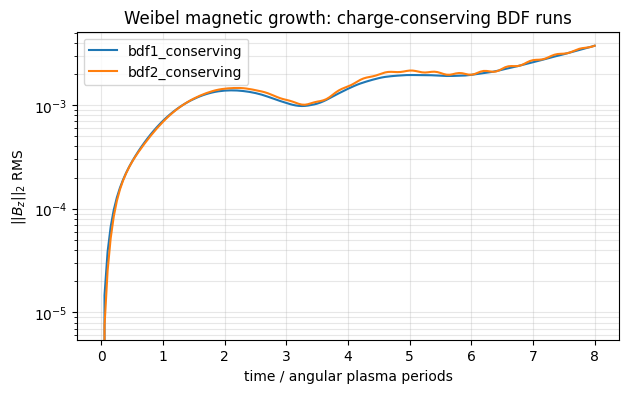

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for prefix in ["weibel_bdf1_conserving", "weibel_bdf2_conserving"]:
    df = diagnostics(prefix)
    ax.semilogy(df["time"], df["Bz_l2"], label=prefix.replace("weibel_", ""))
ax.set_xlabel("time / angular plasma periods")
ax.set_ylabel(r"$||B_z||_2$ RMS")
ax.set_title("Weibel magnetic growth: charge-conserving BDF runs")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()


## Weibel instability: Lorenz gauge and Gauss law

These plots correspond to the role of Figs. 2 and 3 in the paper: compare naive charge redeposition with the continuity-based charge update.


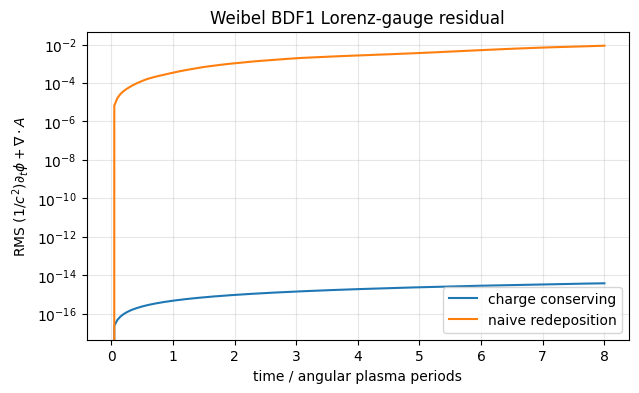

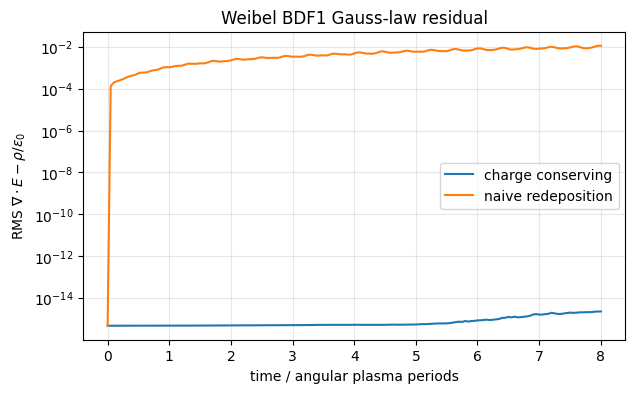

In [5]:
semilogy_pair(
    "weibel_bdf1_conserving",
    "weibel_bdf1_naive",
    "gauge_rms",
    "Weibel BDF1 Lorenz-gauge residual",
    r"RMS $ (1/c^2)\partial_t\phi + \nabla\cdot A $",
)
semilogy_pair(
    "weibel_bdf1_conserving",
    "weibel_bdf1_naive",
    "gauss_rms",
    "Weibel BDF1 Gauss-law residual",
    r"RMS $\nabla\cdot E - \rho/\epsilon_0$",
)


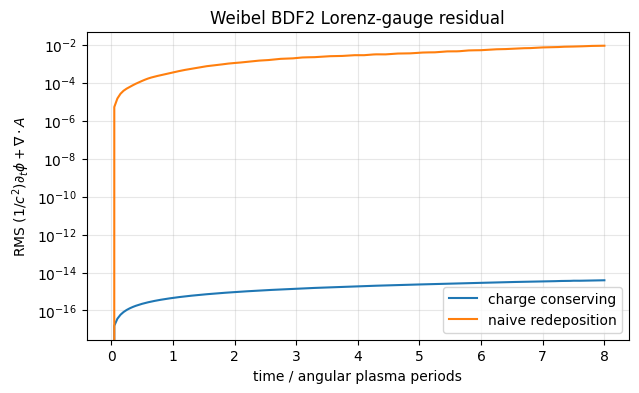

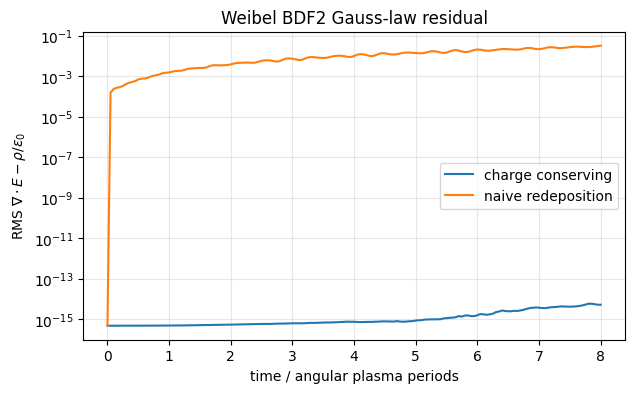

In [6]:
semilogy_pair(
    "weibel_bdf2_conserving",
    "weibel_bdf2_naive",
    "gauge_rms",
    "Weibel BDF2 Lorenz-gauge residual",
    r"RMS $ (1/c^2)\partial_t\phi + \nabla\cdot A $",
)
semilogy_pair(
    "weibel_bdf2_conserving",
    "weibel_bdf2_naive",
    "gauss_rms",
    "Weibel BDF2 Gauss-law residual",
    r"RMS $\nabla\cdot E - \rho/\epsilon_0$",
)


## Drifting cloud: Lorenz gauge and Gauss law

These plots correspond to the role of Figs. 5 and 6 in the paper: the moving cloud is sensitive to gauge and Gauss errors, and the continuity-based charge update should reduce those errors by many orders of magnitude.


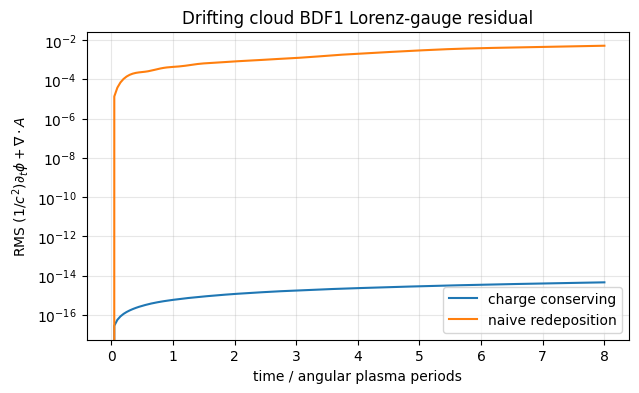

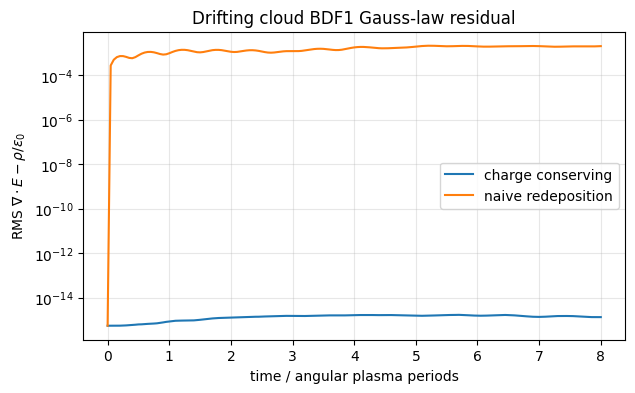

In [7]:
semilogy_pair(
    "cloud_bdf1_conserving",
    "cloud_bdf1_naive",
    "gauge_rms",
    "Drifting cloud BDF1 Lorenz-gauge residual",
    r"RMS $ (1/c^2)\partial_t\phi + \nabla\cdot A $",
)
semilogy_pair(
    "cloud_bdf1_conserving",
    "cloud_bdf1_naive",
    "gauss_rms",
    "Drifting cloud BDF1 Gauss-law residual",
    r"RMS $\nabla\cdot E - \rho/\epsilon_0$",
)


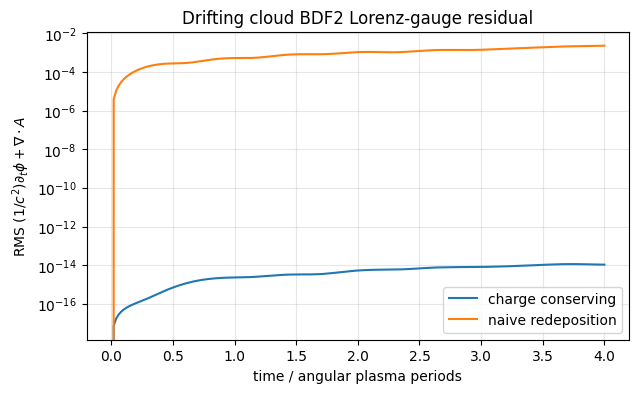

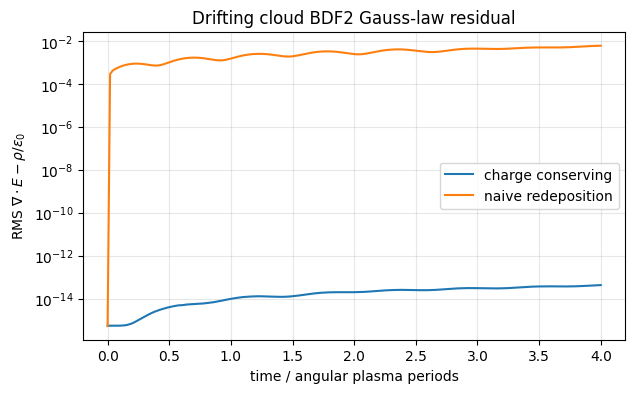

In [8]:
semilogy_pair(
    "cloud_bdf2_conserving",
    "cloud_bdf2_naive",
    "gauge_rms",
    "Drifting cloud BDF2 Lorenz-gauge residual",
    r"RMS $ (1/c^2)\partial_t\phi + \nabla\cdot A $",
)
semilogy_pair(
    "cloud_bdf2_conserving",
    "cloud_bdf2_naive",
    "gauss_rms",
    "Drifting cloud BDF2 Gauss-law residual",
    r"RMS $\nabla\cdot E - \rho/\epsilon_0$",
)


## Drifting cloud particle sample

The C++ code writes a sample of final electron positions. The centered coordinates below use the paper-style `[-L/2,L/2]` view of the periodic domain.


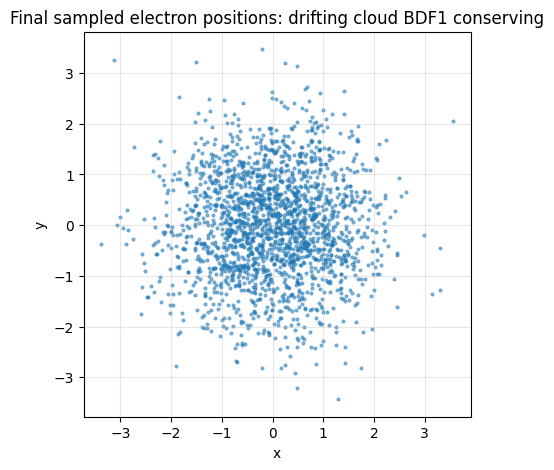

In [9]:
cloud = particle_sample("cloud_bdf1_conserving")
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(cloud["x_centered"], cloud["y_centered"], s=4, alpha=0.5)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Final sampled electron positions: drifting cloud BDF1 conserving")
ax.grid(True, alpha=0.3)
plt.show()


## Energy and speed sanity check

The explicit particle coupling is not the energy-conserving implicit method from the earlier papers. This plot is a sanity check that the lightweight examples stay finite and subluminal.


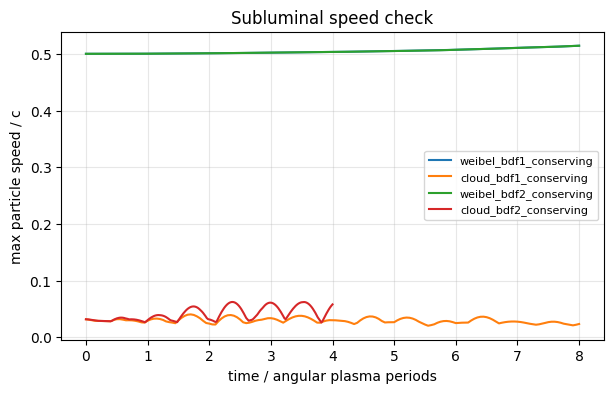

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for prefix in ["weibel_bdf1_conserving", "cloud_bdf1_conserving", "weibel_bdf2_conserving", "cloud_bdf2_conserving"]:
    df = diagnostics(prefix)
    ax.plot(df["time"], df["max_speed"], label=prefix)
ax.set_xlabel("time / angular plasma periods")
ax.set_ylabel("max particle speed / c")
ax.set_title("Subluminal speed check")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.show()
